In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import numpy as np

In [14]:
VARIABLE = "temp" # "edv", "temp", or "heat_index"

assert VARIABLE in ["edv", "temp", "heat_index"], f"invalid `VARIABLE` value: {VARIABLE}"

INPUT_FILE = f"../data/{VARIABLE}/regional_{VARIABLE}_data.csv"
OUTPUT_FILE = f"../data/{VARIABLE}/{VARIABLE}_seasonality.csv"
PLOT_OUTPUT_FILE = f"../plots/seasonality/{VARIABLE}_seasonality.png"
USE_LN = VARIABLE == "edv" # only EDV is transformed since it is a count variable

In [15]:
OMEGA = 1/365.25
PHI = 2*np.pi*OMEGA

def f(t, beta_0, beta_s, beta_c):
    if USE_LN:
        return np.exp(beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t))
    else:
        return beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t)

In [16]:
df = pd.read_csv(INPUT_FILE, index_col=0)
y_min = df.values.min()
y_max = df.values.max()
y_range = y_max - y_min
df.head()

,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
2018-01-01,-15.837069,-10.347318,-7.526191,0.256565,-15.160282,-0.363642,-13.126441,-9.710529,15.798783,-6.738495
2018-01-02,-12.189956,-5.388370,-5.612809,1.883143,-10.613858,1.298075,-4.330759,-1.674502,14.343217,-4.513651
2018-01-03,-5.170511,-3.484295,-2.236547,4.067688,-9.743023,9.192431,-1.263505,-1.196697,14.299780,-4.316342
2018-01-04,-4.535368,-5.003550,-4.980320,2.645091,-12.728201,10.064703,-1.880859,-0.142819,15.886730,-5.315687
2018-01-05,-6.707461,-11.330217,-9.039630,4.140429,-13.790228,13.971358,-2.651693,0.232164,16.154701,-5.215090


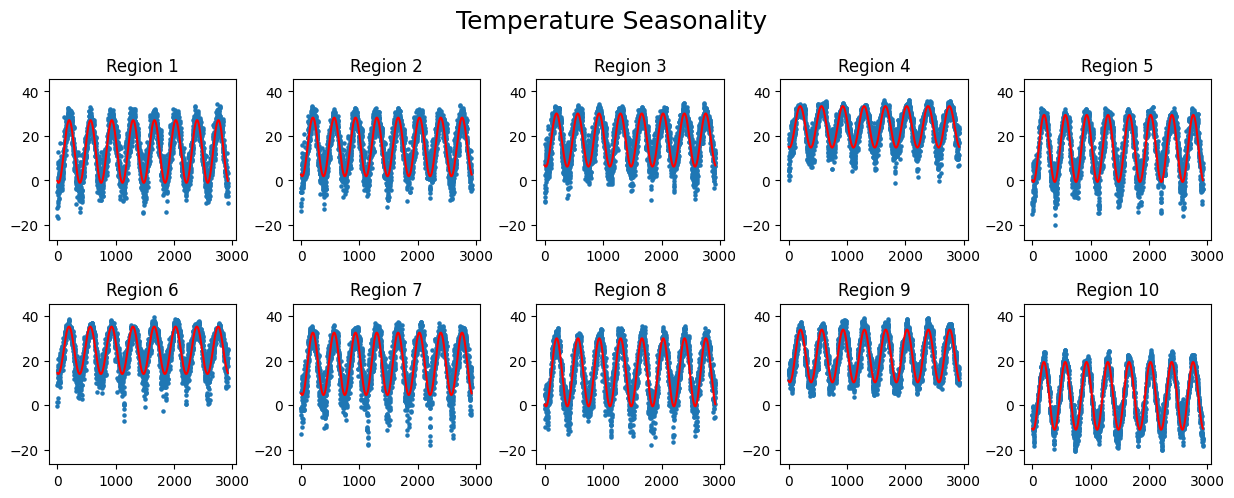

,region,beta_0,beta_s,beta_c,sigma_00,sigma_0s,sigma_0c,sigma_ss,sigma_sc,sigma_cc,psi,var_psi,peak_T,sigma_peak_T,peak_T_CI_lower,peak_T_CI_upper,gamma,var_gamma,theta
0,Region 1,13.010565,-4.729952,-13.265321,0.006375,-2.408704e-12,-5.020732e-13,0.012751,5.787018e-12,0.012751,0.342512,0.000064,202.535657,0.466090,201.622138,203.449176,14.083366,0.012751,1.307158e+06
1,Region 2,15.055915,-4.251360,-12.469139,0.006408,-4.181418e-12,-1.949795e-12,0.012816,1.444200e-11,0.012816,0.328590,0.000074,201.726396,0.499534,200.747328,202.705465,13.173971,0.012816,5.264810e+05
2,Region 3,18.150083,-3.330421,-11.464738,0.006594,-3.005872e-12,-4.909738e-13,0.013187,5.423612e-12,0.013187,0.282712,0.000093,199.059410,0.559152,197.963492,200.155328,11.938673,0.013187,1.530735e+05
3,Region 4,24.080591,-2.408886,-8.997194,0.004195,3.739869e-12,4.472867e-13,0.008390,7.146386e-12,0.008390,0.261602,0.000097,197.832266,0.571685,196.711783,198.952748,9.314087,0.008390,1.109320e+04
4,Region 5,14.384045,-4.562590,-14.350299,0.006912,-5.809672e-12,6.877682e-13,0.013824,-1.008698e-12,0.013824,0.307837,0.000061,200.519960,0.453896,199.630341,201.409579,15.058164,0.013824,3.464795e+06
5,Region 6,24.598266,-2.910669,-10.233774,0.005105,-1.649642e-11,4.239381e-13,0.010210,7.505710e-12,0.010210,0.277101,0.000090,198.733236,0.552071,197.651196,199.815275,10.639649,0.010210,4.175811e+04
6,Region 7,18.510726,-4.304270,-13.332591,0.009455,1.094081e-11,3.782077e-12,0.018911,-8.582711e-12,0.018911,0.312275,0.000096,200.777988,0.570589,199.659654,201.896322,14.010165,0.018911,1.214891e+06
7,Region 8,14.693735,-5.092295,-14.416711,0.007356,-1.135668e-12,3.458883e-13,0.014712,1.233517e-11,0.014712,0.339542,0.000063,202.363034,0.461151,201.459194,203.266874,15.289637,0.014712,4.367221e+06
8,Region 9,22.031183,-4.064919,-11.132850,0.003884,-1.403383e-12,-2.277396e-13,0.007768,1.598797e-11,0.007768,0.350088,0.000055,202.976089,0.432306,202.128786,203.823392,11.851747,0.007768,1.403294e+05
9,Region 10,4.114867,-3.752302,-14.758771,0.003421,-4.996138e-12,-3.062620e-12,0.006843,3.542077e-12,0.006843,0.248967,0.000030,197.097804,0.315769,196.478908,197.716701,15.228299,0.006843,4.107394e+06


In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
data = []
for i, region in enumerate(df.columns):
    x = np.arange(len(df.index))
    y = df[region]
    betas, covs = curve_fit(f, x, y)

    beta_0, beta_s, beta_c = betas
    (sigma_00, sigma_0s, sigma_0c),\
    (_,        sigma_ss, sigma_sc),\
    (_,        _,        sigma_cc) = covs

    psi = np.arctan(beta_s/beta_c)
    var_psi = ((beta_c**2 * sigma_ss) + (beta_s**2 * sigma_cc) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)**2
    if beta_s > 0 and beta_c > 0:
        peak_T = psi / PHI
    elif beta_c < 0:
        peak_T = (psi + np.pi) / PHI
    else:
        peak_T = (psi + 2*np.pi) / PHI
    sigma_peak_T = np.sqrt(var_psi) / PHI
    z = norm.ppf(0.975)
    peak_T_CI = (peak_T - z*sigma_peak_T, peak_T + z*sigma_peak_T)
    gamma = np.sqrt(beta_c**2 + beta_s**2)
    var_gamma = ((beta_c**2 * sigma_cc) + (beta_s**2 * sigma_ss) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)
    theta = np.exp(gamma)
    M = z # M not specified in paper
    theta_CI = (np.exp(gamma - M*np.sqrt(var_gamma)), np.exp(gamma + M*np.sqrt(var_gamma)))

    data.append({
        "region": region,
        "beta_0": beta_0, "beta_s": beta_s, "beta_c": beta_c,
        "sigma_00": sigma_00, "sigma_0s": sigma_0s, "sigma_0c": sigma_0c, "sigma_ss": sigma_ss, "sigma_sc": sigma_sc, "sigma_cc": sigma_cc,
        "psi": psi, "var_psi": var_psi,
        "peak_T": peak_T, "sigma_peak_T": sigma_peak_T, "peak_T_CI_lower": peak_T_CI[0], "peak_T_CI_upper": peak_T_CI[1],
        "gamma": gamma, "var_gamma": var_gamma, "theta": theta,
        # "theta_CI_lower": theta_CI[0], "theta_CI_upper": theta_CI[1]
    })

    ax = axs[i//5,i%5]
    ax.scatter(x, y, s = 5)
    ax.plot(x, f(x, *betas), color = "red")
    ax.set_title(region)
    ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)

if VARIABLE == "edv":
    suptitle = "EDV"
elif VARIABLE == "temp":
    suptitle = "Temperature"
elif VARIABLE == "heat_index":
    suptitle = "Heat Index"
plt.suptitle(f"{suptitle} Seasonality", fontsize = 18, y = 1.02)

plt.savefig(PLOT_OUTPUT_FILE, dpi = 500, bbox_inches = "tight")
plt.show()
df_models = pd.DataFrame(data)
df_models

In [18]:
df_models.to_csv(OUTPUT_FILE, index = False)